# Auto Encoder(AE)

In [32]:
# Autoencoder is a neural network:
# Compress data - Encoder
# Reconstruct data - Decoder

# Original Image > Encoder > Compressed Data > Decoder > Reconstructed Image
# Encoder-Decoder Architecture:
# Input Image (784 pixels) > Encoder > Latent Space(32 values) > Decoder > Reconstructed Image

In [33]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [34]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [35]:
# Normalize
x_train = x_train / 255.0  # Normalize pixel values to [0, 1]
x_test = x_test / 255.0

In [36]:
# Flatten
# Flatten 28x28 images to 784-dimensional vectors, -1 means infer the number of samples
x_train = x_train.reshape(-1, 784) 
x_test = x_test.reshape(-1, 784)

In [37]:
# Encoder
input_img = Input(shape=(784,)) # Input layer for 784-dimensional vectors
encoded = Dense(32, activation='relu')(input_img) # Encoder layer with 32 neurons and ReLU activation

In [38]:
# Decoder
decoded = Dense(784, activation='sigmoid')(encoded) # Decoder layer with 784 neurons and sigmoid activation

In [39]:
# Autoencoder model
autoencoder = Model(input_img, decoded) # Define the autoencoder model with input and output

In [40]:
# Compile the model
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [41]:
# Train the model
autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0712 - val_loss: 0.0414
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0353 - val_loss: 0.0296
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0265 - val_loss: 0.0231
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0213 - val_loss: 0.0190
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0179 - val_loss: 0.0162


In [42]:
# Reconstruction Objective

# Original Image ≈ Reconstructed Image

# If output is different: High Loss
# If output is similar: Low Loss

In [43]:
# MSE Loss - Mean Squared Error

# Original Pixel - Predicted Pixel
# Smaller error = Better reconstruction

In [44]:
# Reconstruct images
reconstructed = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


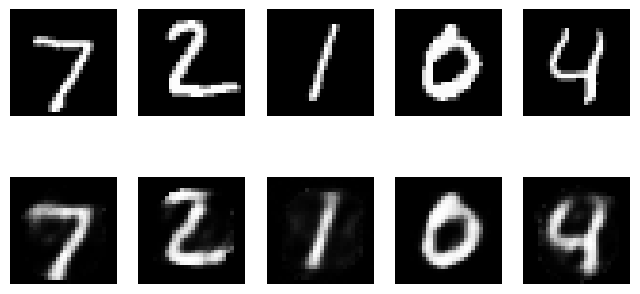

In [45]:
plt.figure(figsize=(8,4))

for i in range(5):

    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

### Use Cases

In [46]:
# Image Compression 

# Create encoder model to extract compressed representations
encoder = Model(input_img, encoded)

compressed = encoder.predict(x_test)

print(compressed.shape)

# Compressed data has 32 values per image, significantly reducing the dimensionality from 784 to 32.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(10000, 32)


In [47]:
# Denoising Autoencoder - Old photo contains noise.

# Input = Noisy image
# Target = Clean image

import numpy as np

noise_factor = 0.3

x_train_noisy = x_train + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0165
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0149
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0146
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0144
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0143


# Variational Autoencoder (VAE)

In [48]:
# AE can compress images, But cannot generate new images properly
# VAE can: Compress, Generate new images, Create unseen images

# VAE Architecture
# Image > Encoder > Mean (μ), Variance (σ) > Sampling > Decoder > Generated Image

In [49]:
# Probabilistic Latent Space

# AE: One fixed point
# VAE: Probability distribution

# Instead of storing : x = 3,  Store: Mean = 3, Variance = 0.5

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

latent_dim = 2

encoder_inputs = tf.keras.Input(shape=(784,)) 

x = layers.Dense(128, activation='relu')(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x) 
z_log_var = layers.Dense(latent_dim)(x)

In [51]:
def sampling(args):
    z_mean, z_log_var = args

    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5*z_log_var)*epsilon

In [52]:
z = layers.Lambda(sampling)([z_mean,z_log_var]) 
# Sampling layer to generate latent vector from mean and log variance

### KL Divergence

In [53]:
# VAE has two losses  ---->  Total Loss = Reconstruction Loss + KL Loss

# 1.Reconstruction Loss
# Generated image ≈ Original image

# 2. KL Loss
# Keeps latent space organized.

# Without KL: Random messy space
# With KL: Smooth structured space
